# **Lesson_5.1**

## In this lecture

* Fork repository

* K-means clustering: cluster prediction for an individual input
* How to save and reuse your trained model
* In-class exercise: clustering helper function
* Linear regression code-along walkthrough project **Medical Charges**
* In-class exercise: medical data clustering

---

## Cluster prediction for an individual input

#### Prepare input
The new person (customer) is:
* Age: 30
* Annual income: 60k
* Spending score: 50

#### Create input for this customer:

In [1]:
import pandas as pd
import joblib

In [3]:
new_customer_df = pd.DataFrame([[30, 60, 50]], columns=['Age', 'Annual_Income', 'Spending_Score'])  # N.b.: _2D_array_
new_customer_df

,Age,Annual_Income,Spending_Score
0,30,60,50


#### Predict the cluster

In [4]:
kmeans = joblib.load("../models/kmeans_v1.pkl")
kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [5]:
cluster_label = kmeans.predict(new_customer_df)
print(f"The customer belongs to cluster: {cluster_label[0]}")

The customer belongs to cluster: 3



<fieldset>
<legend>DANGER ZONE</legend>
If you apply any preprocessing to your original dataset (like PCA, scaling ...), you should apply the same to the <b>new_customer_df</b> otherwise prediction will be wrong!
</fieldset>

In [6]:
distances = kmeans.transform(new_customer_df)
print("Distances to cluster centers:", distances)

Distances to cluster centers: [[26.99624116 44.76195542 45.37829969  4.57425652 41.75835277 48.41321103]]


### In-class exercise

Write a helper function which would ask a user to enter *age*, *annual income* and *spending score* and **return** which *cluster* the new customer belongs to.

In [2]:
# Write your code here ...
import pandas as pd
import joblib
age = input('Enter age?')
annual_income= input('Enter annual income?')
spending_score= input('Enter spending score?')
new_customer_df = pd.DataFrame([[age, annual_income, spending_score]], columns=['Age', 'Annual_Income', 'Spending_Score'])  # N.b.: _2D_array_
new_customer_df
kmeans = joblib.load("../models/kmeans_v1.pkl")
kmeans
cluster_label = kmeans.predict(new_customer_df)
print(f"The customer belongs to cluster: {cluster_label[0]}")


The customer belongs to cluster: 5


---

## Linear regression model for Medical Charges prediction

### Business objectives

* Purpose of the project: Predicting medical expences using Linear Regression
* Business question: what would be medical charges for new customers?

### Import and settings

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px # Interactive charts and save some coding; .express - high-level api
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Change settings to improve default style (optional)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

### Load data

In [5]:
# Data path
data_path = '../datasets/medical-charges.csv'

# Load data
medical_df = pd.read_csv(data_path)

### EDA

In [6]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Visualisation

* Age

In [10]:
fig = px.histogram(
    medical_df,
    x='age',
    marginal='box',
    nbins=47, # bin for each year. Calculated from min and max age in the dataset.
    title="Age distribution"
)
fig.update_layout(bargap=0.1)
fig.show()

* BMI

In [11]:
fig = px.histogram(
    medical_df,
    x='bmi',
    marginal='box',
    color_discrete_sequence=['red'],
    nbins=47, # bin for each year. Calculated from min and max age in the dataset.
    title="BMI distribution"
)
fig.update_layout(bargap=0.1)
fig.show()

* Charges

In [ ]:
fig = px.histogram(
    medical_df,
    x='charges',
    # color='smoker',
    marginal='box',
    # color_discrete_sequence=['green', 'grey'],
    nbins=47, # bin for each year. Calculated from min and max age in the dataset.
    title="Annual medical charges"
)
fig.update_layout(bargap=0.1)
fig.show()

* Smoker

In [ ]:
medical_df.smoker.value_counts()

In [ ]:
fig = px.histogram(
    medical_df,
    x='smoker',
    color='sex',
    title="Smoker"
)

fig.show()

* Age and charges

In [ ]:
fig = px.scatter(
    medical_df,
    x='age',
    y='charges',
    color='smoker',
    opacity=0.8,
    hover_data=['sex'],
    title="Age vs. Charges"    
)
fig.update_traces(marker_size=5)
fig.show()

* BMI and charges

In [ ]:
fig = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    opacity=0.8,
    hover_data=['sex'],
    title="BMI vs. Charges"    
)
fig.update_traces(marker_size=5)
fig.show()

* Number of children

In [ ]:
fig = px.violin(  # Violing used as an example
    medical_df,
    x='children',
    y='charges'
)
fig.show()

### In-class exercise
Before we proceed with building **linear regression model** to predict medical charges, apply k-means clustering using all applicable numerical features in the dataset (reuse the workflow we studied in the previous lesson).

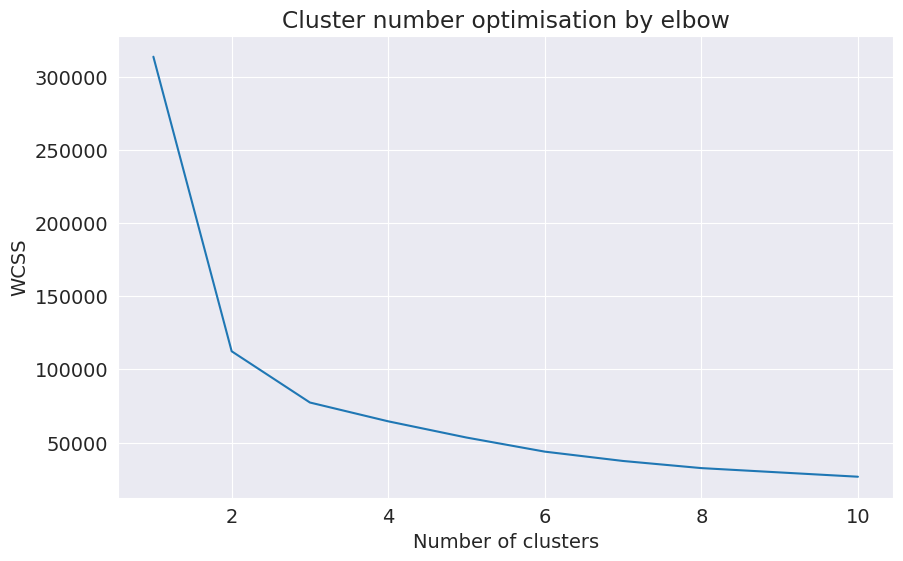

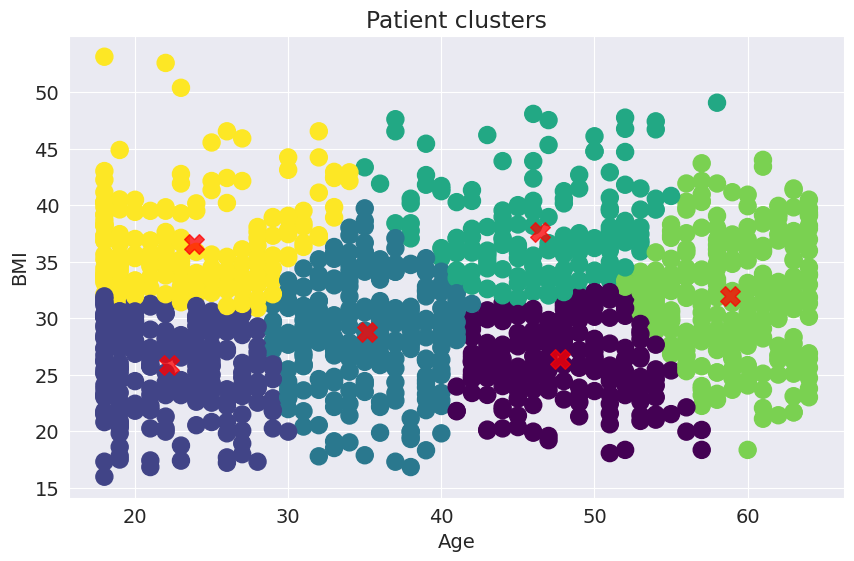

In [18]:
from sklearn.cluster import KMeans
data_path = '../datasets/medical-charges.csv'

# Load data
df = pd.read_csv(data_path)

Y = df[['age', 'bmi']]

wscc_ab = []
for i in range(1, 11):
    kmean_ab = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmean_ab.fit(Y)
    wscc_ab.append(kmean_ab.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wscc_ab)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Cluster number optimisation by elbow")
plt.show()

kmean_ab = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)

y_ab_kmeans = kmeans.fit_predict(Y)
df['Cluster'] = y_ab_kmeans
df.head()

plt.figure(figsize=(10, 6))
plt.scatter(Y.iloc[:,0], Y.iloc[:,1], c=y_ab_kmeans, s=150, cmap='viridis')  # review slicing through iterables; 0, 1 stands for columns
centers = kmeans.cluster_centers_  # Retrieves coordinates of cluster centers
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, alpha=.75, marker='X')
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Patient clusters")
plt.show()


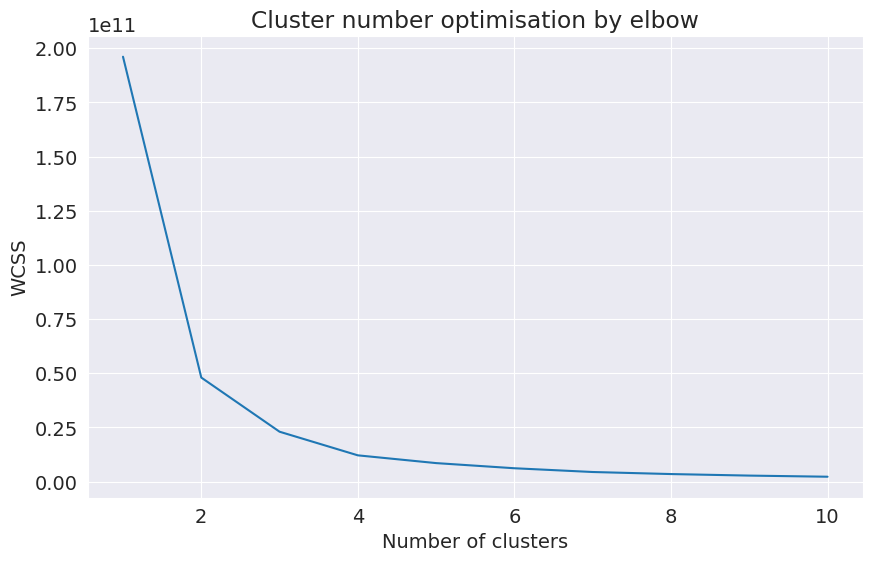

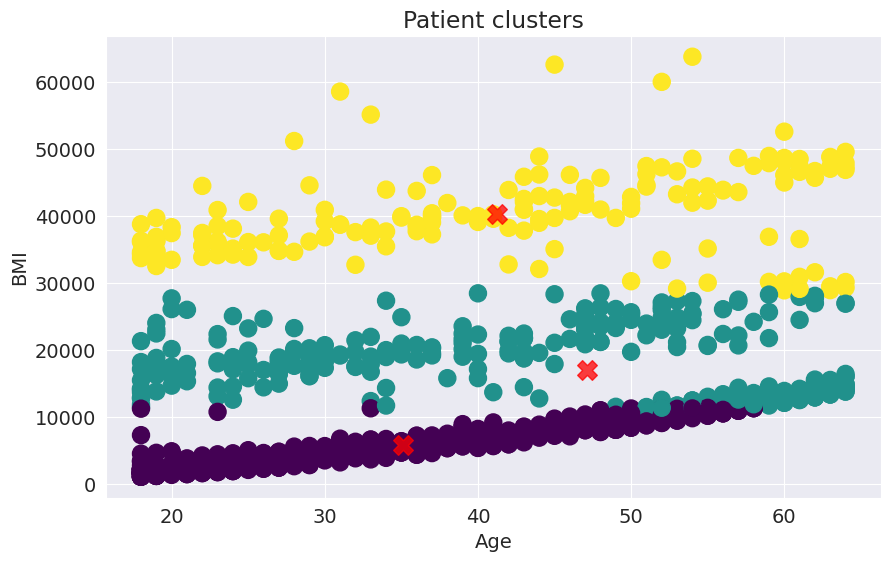

In [22]:
A = df[['age', 'charges']]

wscc_ac = []
for i in range(1, 11):
    kmean_ac = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmean_ac.fit(A)
    wscc_ac.append(kmean_ac.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wscc_ac)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Cluster number optimisation by elbow")
plt.show()

kmean_ac = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)

y_ac_kmeans = kmean_ac.fit_predict(A)
df['Cluster'] = y_ac_kmeans
df.head()

plt.figure(figsize=(10, 6))
plt.scatter(A.iloc[:,0], A.iloc[:,1], c=y_ac_kmeans, s=150, cmap='viridis')  # review slicing through iterables; 0, 1 stands for columns
centers = kmean_ac.cluster_centers_  # Retrieves coordinates of cluster centers
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, alpha=.75, marker='X')
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Patient clusters")
plt.show()


---

##### Reminder: do not forget to **Clear All Outputs**
### Now you can commit and push your code to **GitHub**